# AeroSense — Kaggle run: explore → prepare → train

Run cells top to bottom. **Before starting:** Settings → Accelerator = **GPU T4**, Internet = **On**,
and both datasets attached (`orvile/coughvid-v3`, `vbookshelf/respiratory-sound-database`).

## 0. Get the code and check the environment

In [1]:
import os, sys, shutil, subprocess

REPO_URL = "https://github.com/afiyaaman2512/AeroSense"   # <-- CHANGE THIS
REPO = "/kaggle/working/AeroSense"

if not os.path.exists(REPO):
    r = subprocess.run(["git", "clone", REPO_URL, REPO], capture_output=True, text=True)
    print(r.stdout or r.stderr)
assert os.path.exists(f"{REPO}/src/config.py"), (
    "Code not found. Fix REPO_URL (repo must be public), or upload your src/ folder "
    "so that /kaggle/working/AeroSense/src/config.py exists.")

os.chdir(REPO)
sys.path.insert(0, f"{REPO}/src")

import torch
print("torch", torch.__version__, "| GPU available:", torch.cuda.is_available())
print("ffmpeg:", shutil.which("ffmpeg"))
from config import ON_KAGGLE, COUGHVID_AUDIO_DIR, ICBHI_AUDIO_DIR
print("on kaggle:", ON_KAGGLE, "\ncoughvid audio dir exists:", COUGHVID_AUDIO_DIR.exists(),
      "\nicbhi audio dir exists:", ICBHI_AUDIO_DIR.exists())

Cloning into '/kaggle/working/AeroSense'...

torch 2.10.0+cu128 | GPU available: True
ffmpeg: /usr/bin/ffmpeg
on kaggle: True 
coughvid audio dir exists: True 
icbhi audio dir exists: True


## 1. Build the manifests (labels → normal / abnormal)

In [2]:
import pandas as pd
from manifest import build_coughvid_manifest, build_icbhi_manifest, assign_splits

coughvid_df = build_coughvid_manifest()
coughvid_df = assign_splits(coughvid_df, train_frac=0.85)   # stratified by label
coughvid_df.head()

[coughvid] 66 expert-labeled rows in filtered_expert_labels_coughvid_v3.csv
[coughvid] distinct expert diagnosis values: ['COVID-19', 'healthy_cough', 'lower_infection', 'obstructive_disease', 'upper_infection']
[coughvid] after cough-confidence filter: 52/66
[coughvid] after dropping poor/no_cough quality: 52
[coughvid] after majority-vote labeling (ties dropped): 46
[coughvid] indexed 34434 audio files in coughvid_20211012
[coughvid] final: 46 clips
label
abnormal    43
normal       3


,filepath,label,dataset,self_reported_status,split
0,/kaggle/input/datasets/orvile/coughvid-v3/publ...,abnormal,coughvid,symptomatic,train
1,/kaggle/input/datasets/orvile/coughvid-v3/publ...,abnormal,coughvid,symptomatic,train
2,/kaggle/input/datasets/orvile/coughvid-v3/publ...,abnormal,coughvid,COVID-19,train
3,/kaggle/input/datasets/orvile/coughvid-v3/publ...,abnormal,coughvid,symptomatic,train
4,/kaggle/input/datasets/orvile/coughvid-v3/publ...,abnormal,coughvid,healthy,train


In [3]:
icbhi_df = build_icbhi_manifest()
icbhi_df["split"] = "test"      # frozen external test set: never used for training/selection
icbhi_df.head()

[icbhi] diagnoses for 126 patients: [('COPD', 64), ('Healthy', 26), ('URTI', 14), ('Bronchiectasis', 7), ('Pneumonia', 6), ('Bronchiolitis', 6), ('LRTI', 2), ('Asthma', 1)]
[icbhi] 920 annotation files
[icbhi] final: 6898 cycles from 126 patients
label
abnormal    6576
normal       322


,filepath,label,dataset,start_s,end_s,has_crackle,has_wheeze,patient_id,diagnosis,split
0,/kaggle/input/datasets/vbookshelf/respiratory-...,abnormal,icbhi,0.036,0.579,False,False,101,URTI,test
1,/kaggle/input/datasets/vbookshelf/respiratory-...,abnormal,icbhi,0.579,2.450,False,False,101,URTI,test
2,/kaggle/input/datasets/vbookshelf/respiratory-...,abnormal,icbhi,2.450,3.893,False,False,101,URTI,test
3,/kaggle/input/datasets/vbookshelf/respiratory-...,abnormal,icbhi,3.893,5.793,False,False,101,URTI,test
4,/kaggle/input/datasets/vbookshelf/respiratory-...,abnormal,icbhi,5.793,7.521,False,False,101,URTI,test


## 2. Decode audio once to 16 kHz wav
COUGHVID mixes webm/ogg/wav; decoding webm every epoch would be very slow. This runs once (a few minutes).

In [4]:
from cache_audio import cache_manifest_audio

combined = pd.concat([coughvid_df, icbhi_df], ignore_index=True, sort=False)
combined = cache_manifest_audio(combined)
combined["dataset"].value_counts()

decoding audio: 100%|██████████| 966/966 [01:01<00:00, 15.75it/s]


[cache] decoded 966/966 files (0 failed)
[cache] rows kept: 6944/6944


dataset
icbhi       6898
coughvid      46
Name: count, dtype: int64

## 3. Explore: class balance, durations, example spectrograms

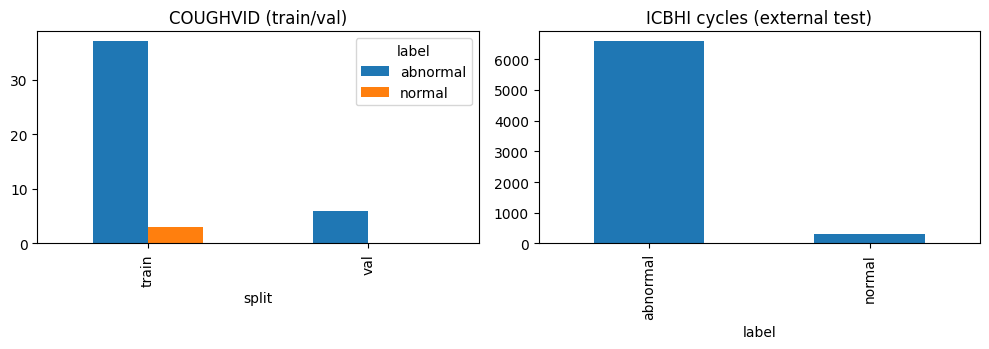

COUGHVID label balance:
 label
abnormal    0.935
normal      0.065
Name: proportion, dtype: float64

ICBHI label balance:
 label
abnormal    0.953
normal      0.047
Name: proportion, dtype: float64

ICBHI patients per label:
 label
abnormal    100
normal       26
Name: patient_id, dtype: int64


In [5]:
import matplotlib.pyplot as plt, numpy as np, soundfile as sf
from config import FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cv = combined[combined.dataset == "coughvid"]
ic = combined[combined.dataset == "icbhi"]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
cv.groupby(["split", "label"]).size().unstack().plot.bar(ax=ax[0], title="COUGHVID (train/val)")
ic["label"].value_counts().plot.bar(ax=ax[1], title="ICBHI cycles (external test)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150); plt.show()

print("COUGHVID label balance:\n", cv["label"].value_counts(normalize=True).round(3))
print("\nICBHI label balance:\n", ic["label"].value_counts(normalize=True).round(3))
print("\nICBHI patients per label:\n", ic.groupby("label")["patient_id"].nunique())

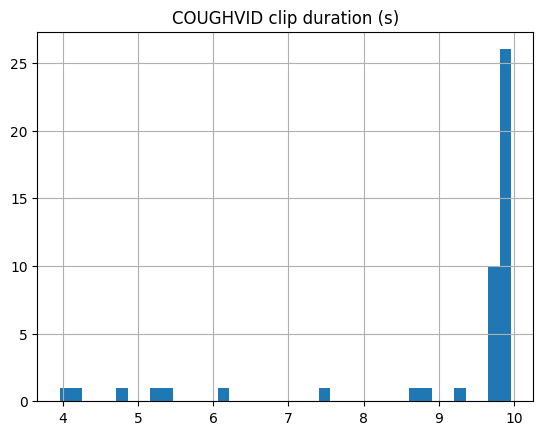

count    46.00
mean      9.10
std       1.71
min       3.96
25%       9.68
50%       9.84
75%       9.90
max       9.96
Name: filepath, dtype: float64

ICBHI cycle length (s):
 count    6898.00
mean        2.70
std         1.17
min         0.20
25%         1.93
50%         2.54
75%         3.37
max        16.16
dtype: float64


In [6]:
# clip durations (cached wavs are plain wav, so this is instant)
dur = cv["filepath"].apply(lambda p: sf.info(p).duration)
dur.hist(bins=40); plt.title("COUGHVID clip duration (s)"); plt.show()
print(dur.describe().round(2))
ic_len = ic["end_s"] - ic["start_s"]
print("\nICBHI cycle length (s):\n", ic_len.describe().round(2))

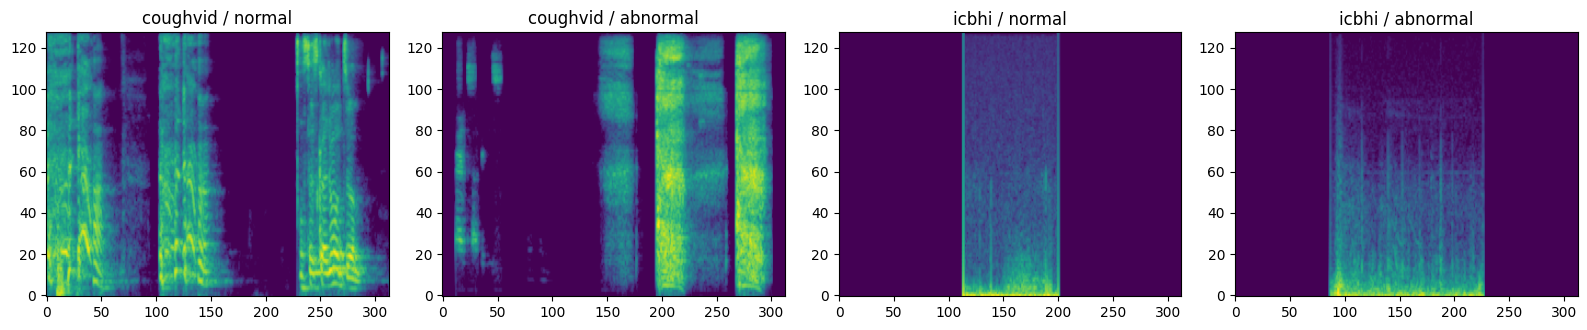

In [7]:
import librosa.display
from preprocessing import preprocess_file
from spectrogram import audio_to_melspectrogram

samples = pd.concat([cv[cv.label == "normal"].sample(1, random_state=1),
                     cv[cv.label == "abnormal"].sample(1, random_state=1),
                     ic[ic.label == "normal"].sample(1, random_state=1),
                     ic[ic.label == "abnormal"].sample(1, random_state=1)])
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, (_, r) in zip(axes, samples.iterrows()):
    seg = (r.start_s, r.end_s) if pd.notna(r.get("start_s")) else None
    S = audio_to_melspectrogram(preprocess_file(r.filepath, segment=seg))
    ax.imshow(S, origin="lower", aspect="auto"); ax.set_title(f"{r.dataset} / {r.label}")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "example_spectrograms.png", dpi=150); plt.show()

## 4. Findings to note (fill in)
- COUGHVID normal/abnormal ratio: **TODO** → if very skewed, class weights in `train.py` matter
- ICBHI normal/abnormal ratio: **TODO** (ICBHI is mostly diseased patients — accuracy alone will mislead; use per-class recall)
- **Domain caveat:** COUGHVID = phone-recorded coughs; ICBHI = stethoscope lung sounds. The cross-dataset test measures how well a cough-trained model transfers to a very different signal — expect a large drop, and report it honestly rather than tuning on ICBHI.

## 5. Save the manifest

In [8]:
from config import DATA_PROCESSED_DIR
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
combined.to_csv(DATA_PROCESSED_DIR / "manifest.csv", index=False)
print(combined.groupby(["dataset", "split", "label"]).size())

dataset   split  label   
coughvid  train  abnormal      37
                 normal         3
          val    abnormal       6
icbhi     test   abnormal    6576
                 normal       322
dtype: int64


## 6. Quick smoke test (1 epoch), then the real training run

In [9]:
!python src/model.py
!python src/train.py --epochs 1 --num-workers 2

input shape:  (4, 1, 128, 313)
output shape: (4, 2)  (expected: (4, 2))
trainable parameters: 97,890
[device] cuda
[labels] {'abnormal': 0, 'normal': 1}
[data] train=40  val=6
[class weights] {'abnormal': 0.5405405163764954, 'normal': 6.666666507720947}
[model] 97,890 trainable parameters
epoch 01/1 | train_loss=0.6535 train_acc=0.688 | val_loss=0.6332 val_acc=1.000
  -> new best (val_acc=1.000), checkpoint saved
[done] best val_acc=1.000 | checkpoint -> /kaggle/working/AeroSense/models/baseline_cnn_best.pt | history -> /kaggle/working/AeroSense/models/training_history.json


In [10]:
!python src/train.py --epochs 25 --num-workers 2

[device] cuda
[labels] {'abnormal': 0, 'normal': 1}
[data] train=40  val=6
[class weights] {'abnormal': 0.5405405163764954, 'normal': 6.666666507720947}
[model] 97,890 trainable parameters
epoch 01/25 | train_loss=0.6948 train_acc=0.656 | val_loss=0.6473 val_acc=1.000
  -> new best (val_acc=1.000), checkpoint saved
epoch 02/25 | train_loss=0.6871 train_acc=0.625 | val_loss=0.6570 val_acc=1.000
epoch 03/25 | train_loss=0.7407 train_acc=0.594 | val_loss=0.6616 val_acc=1.000
epoch 04/25 | train_loss=0.6545 train_acc=0.656 | val_loss=0.6689 val_acc=1.000
epoch 05/25 | train_loss=0.5825 train_acc=0.750 | val_loss=0.6870 val_acc=0.667
epoch 06/25 | train_loss=0.6514 train_acc=0.781 | val_loss=0.7097 val_acc=0.167
epoch 07/25 | train_loss=0.6940 train_acc=0.688 | val_loss=0.7363 val_acc=0.167
[early stop] no improvement for 6 epochs
[done] best val_acc=1.000 | checkpoint -> /kaggle/working/AeroSense/models/baseline_cnn_best.pt | history -> /kaggle/working/AeroSense/models/training_history.jso

After training: `models/baseline_cnn_best.pt` and `training_history.json` are in `/kaggle/working/AeroSense/models/`.
Click **Save Version → Save & Run All** to keep them as notebook output, or download them from the Output tab.